# ERROR ANALYSIS & INTERPRETABILITY

### LIBRARY

In [12]:
# IMPORT CORE LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import seaborn as sns

# SKLEARN METRICS FOR ERROR ANALYSIS
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# LIME FOR EXPLAINABILITY
from lime.lime_text import LimeTextExplainer

# SHAP FOR GLOBAL AND LOCAL FEATURE EXPLANATION
import shap

import joblib

from IPython.display import display, HTML

### LOAD DATA AND MODEL (LOGISTIC REGRESSION + TFIDF)

In [13]:
# LOAD TRAINED LOGISTIC REGRESSION MODEL AND TF-IDF VECTORIZER
# THESE FILES WERE SAVED PREVIOUSLY AND WILL BE LOADED TO MAKE PREDICTIONS
model = joblib.load("../MODEL/MODELS/ML/LOGISTIC_TFIDF.pkl")
vectorizer = joblib.load("../MODEL/VECTORIZER/TFIDF_VECTORIZER.pkl")

# LOAD CLEANED TEST DATA
# READ THE DATA FROM THE CSV FILE CONTAINING CLEANED TEXT AND LABELS
df = pd.read_csv("../DATA/DATA[C].csv")

# TEXT COLUMN AND LABEL
# DEFINE X_TEXT AS THE COLUMN CONTAINING THE CLEANED TEXT AND Y_TRUE AS THE TRUE LABELS
X_text = df['clean_text']
y_true = df['label']

# HANDLE NaN VALUES IN THE TEXT COLUMN
# CHECK IF THERE ARE ANY NaN VALUES IN 'clean_text' AND REPLACE THEM WITH EMPTY STRINGS
if df['clean_text'].isna().any():
    print("WARNING: THERE ARE NaN VALUES IN THE clean_text COLUMN. THESE WILL BE HANDLED.")
    df['clean_text'] = df['clean_text'].fillna('')  # REPLACE NaN WITH EMPTY STRING

# TRANSFORM TEXT TO FEATURES
# USE THE VECTORIZER TO CONVERT TEXT DOCUMENTS INTO A DOCUMENT-TERM MATRIX
X_vectorized = vectorizer.transform(df['clean_text'])

# PREDICT CLASSES AND PROBABILITIES
# PREDICT THE CLASS LABELS AND THE PROBABILITIES OF THE POSITIVE CLASS (INDEX 1) USING THE LOADED MODEL
y_pred = model.predict(X_vectorized)
y_prob = model.predict_proba(X_vectorized)[:, 1]  # PROBABILITY FOR THE POSITIVE CLASS (CLASS 1)

# PRINT RESULTS
# YOU CAN PRINT OR LOG THE PREDICTIONS AND PROBABILITIES TO VERIFY
print("PREDICTIONS -->", y_pred)
print("PROBABILITIES FOR CLASS 1 -->", y_prob)

PREDICTIONS --> [0 1 1 ... 1 1 0]
PROBABILITIES FOR CLASS 1 --> [0.0251355  0.97480022 0.92177072 ... 0.99905555 0.97721995 0.02367984]


### PERFORMANCE METRICS & CONFUSION MATRIX

ACCURACY --> 0.9870
PRECISION --> 0.9838
RECALL --> 0.9926
F1-SCORE --> 0.9882

CLASSIFICATION REPORT -->

              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.99     17455
        REAL       0.98      0.99      0.99     21192

    accuracy                           0.99     38647
   macro avg       0.99      0.99      0.99     38647
weighted avg       0.99      0.99      0.99     38647



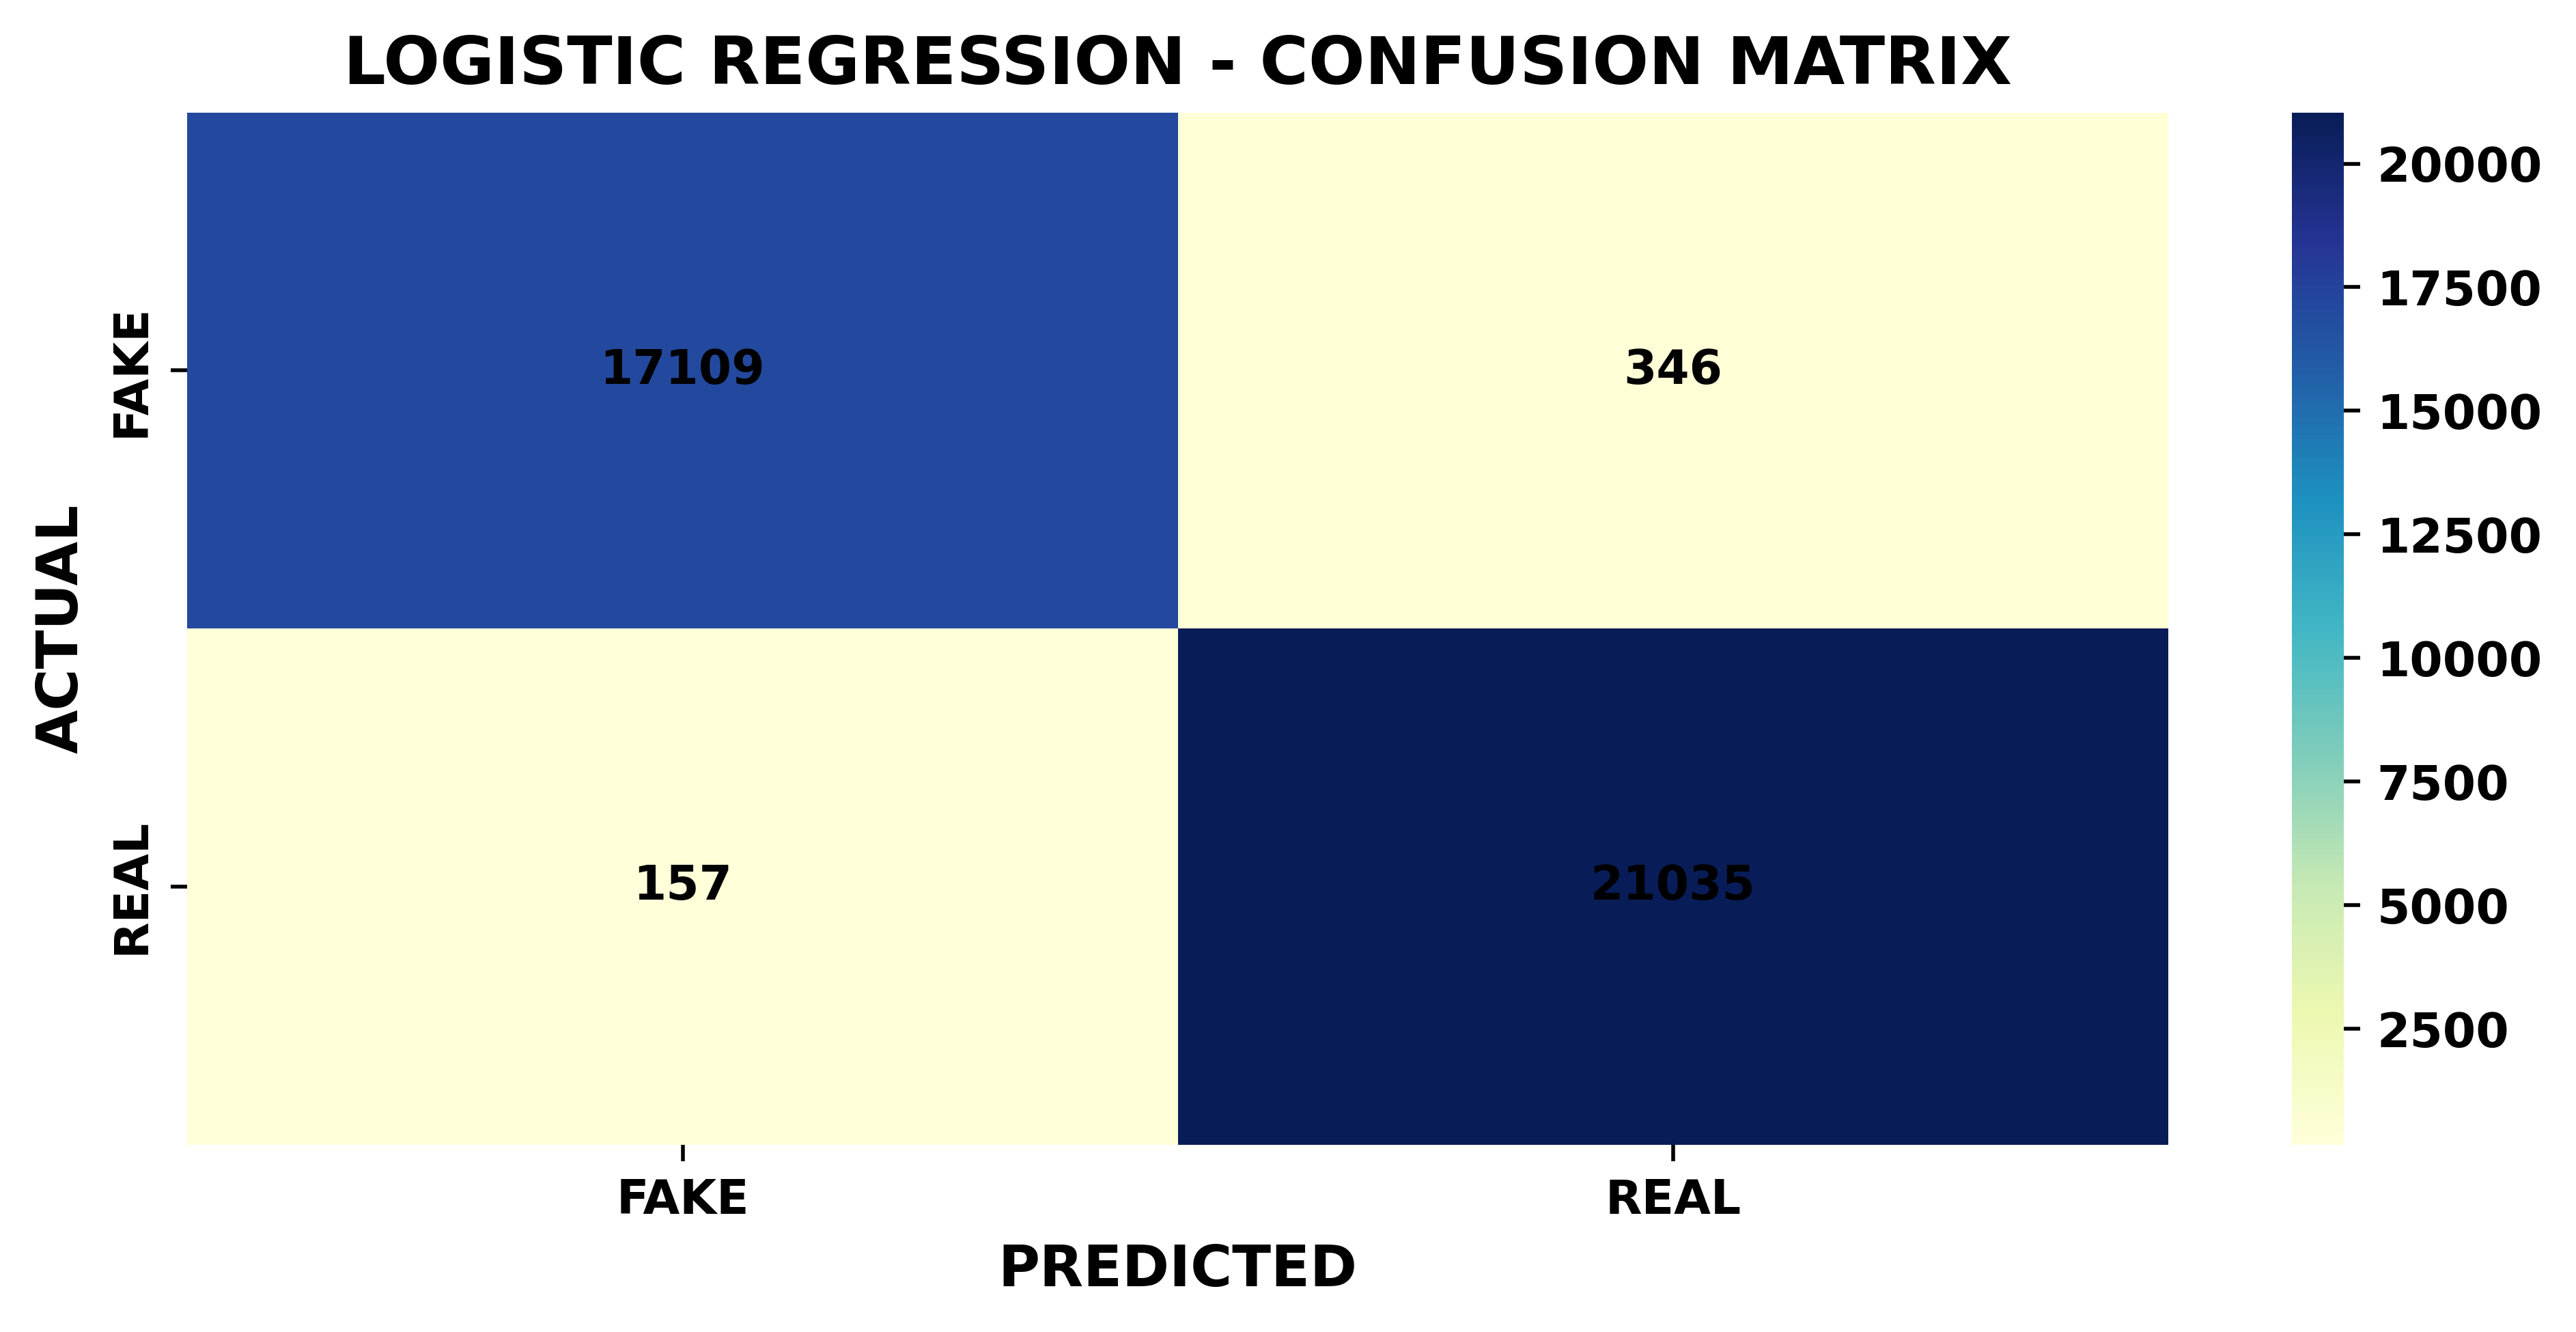

In [14]:
# CALCULATE METRICS
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# DISPLAY METRICS
print(f"ACCURACY --> {acc:.4f}")
print(f"PRECISION --> {prec:.4f}")
print(f"RECALL --> {rec:.4f}")
print(f"F1-SCORE --> {f1:.4f}")
print("\nCLASSIFICATION REPORT -->\n")
print(classification_report(y_true, y_pred, target_names=["FAKE", "REAL"]))

# PLOT CONFUSION MATRIX

# CALCULATE CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

# CREATE HIGH-RESOLUTION FIGURE
plt.figure(figsize=(8, 4), dpi=500)

# DEFINE BOLD FONT PROPERTIES FOR AXIS LABELS AND TICKS
bold_font = FontProperties(weight='bold', size=10)

# PLOT THE HEATMAP WITH BOLD FONT IN CELLS
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    xticklabels=["FAKE", "REAL"],
    yticklabels=["FAKE", "REAL"],
    annot_kws={"weight": "bold", "fontsize": 10, "color": "black"}
)

# SET TITLE AND AXIS LABELS IN BOLD
plt.title("LOGISTIC REGRESSION - CONFUSION MATRIX", fontsize=14, fontweight='bold', color='black')
plt.xlabel("PREDICTED", fontsize=12, fontweight='bold', color='black')
plt.ylabel("ACTUAL", fontsize=12, fontweight='bold', color='black')

# SET TICK LABELS TO BOLD AND BLACK
ax.set_xticklabels(ax.get_xticklabels(), fontproperties=bold_font, color='black')
ax.set_yticklabels(ax.get_yticklabels(), fontproperties=bold_font, color='black')

# SET COLORBAR LABELS TO BOLD
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(labelsize=10)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

# ENHANCE BORDER THICKNESS AND COLOR
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# OPTIMIZE LAYOUT
plt.tight_layout()
plt.show()